<a href="https://colab.research.google.com/github/ayaz-ali-36/Machine-Learning/blob/main/Unsupervised/unspuervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA


import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


In [3]:
url = "https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2024%20-%20K-Means%20Clustering/Mall_Customers.csv"
df = pd.read_csv(url)

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head()

Shape: (200, 5)

Columns: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Missing values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:

df = df.drop('CustomerID', axis=1)


df['Genre'] = df['Genre'].map({'Male': 0, 'Female': 1})

X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


print(f"Shape: {X_scaled.shape}")
print(X_scaled.describe().round(2))

Shape: (200, 3)
          Age  Annual Income (k$)  Spending Score (1-100)
count  200.00              200.00                  200.00
mean    -0.00               -0.00                   -0.00
std      1.00                1.00                    1.00
min     -1.50               -1.74                   -1.91
25%     -0.72               -0.73                   -0.60
50%     -0.20                0.04                   -0.01
75%      0.73                0.67                    0.89
max      2.24                2.92                    1.89


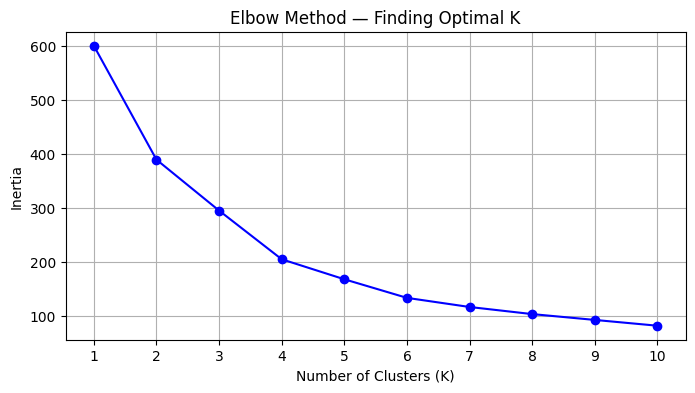

In [5]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Finding Optimal K')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [7]:

silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k}: Silhouette={score:.3f}")

best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\n Best K by Silhouette: {best_k}")

K=2: Silhouette=0.335
K=3: Silhouette=0.358
K=4: Silhouette=0.404
K=5: Silhouette=0.417
K=6: Silhouette=0.428
K=7: Silhouette=0.417
K=8: Silhouette=0.408
K=9: Silhouette=0.418
K=10: Silhouette=0.407

 Best K by Silhouette: 6


In [10]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)


print("Cluster Profiles:")
print(df.groupby('Cluster')[['Age', 'Annual Income (k$)',
                              'Spending Score (1-100)']].mean().round(1))

Cluster Profiles:
          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0        56.3                54.3                    49.1
1        26.8                57.1                    48.1
2        41.9                88.9                    17.0
3        32.7                86.5                    82.1
4        25.0                25.3                    77.6
5        45.5                26.3                    19.4


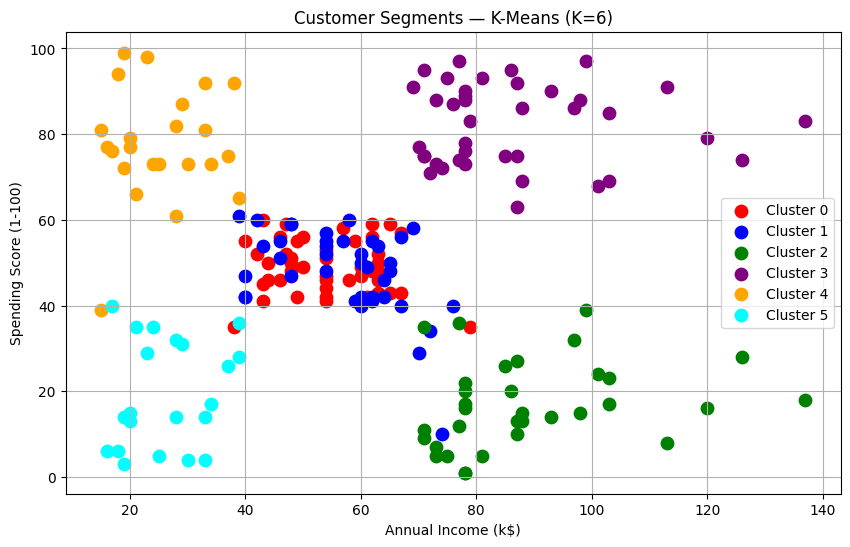

In [11]:
plt.figure(figsize=(10, 6))
colors = ['red','blue','green','purple','orange','cyan']

for cluster in range(6):
    mask = df['Cluster'] == cluster
    plt.scatter(
        df[mask]['Annual Income (k$)'],
        df[mask]['Spending Score (1-100)'],
        c=colors[cluster],
        label=f'Cluster {cluster}',
        s=80
    )

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments — K-Means (K=6)')
plt.legend()
plt.grid(True)
plt.show()

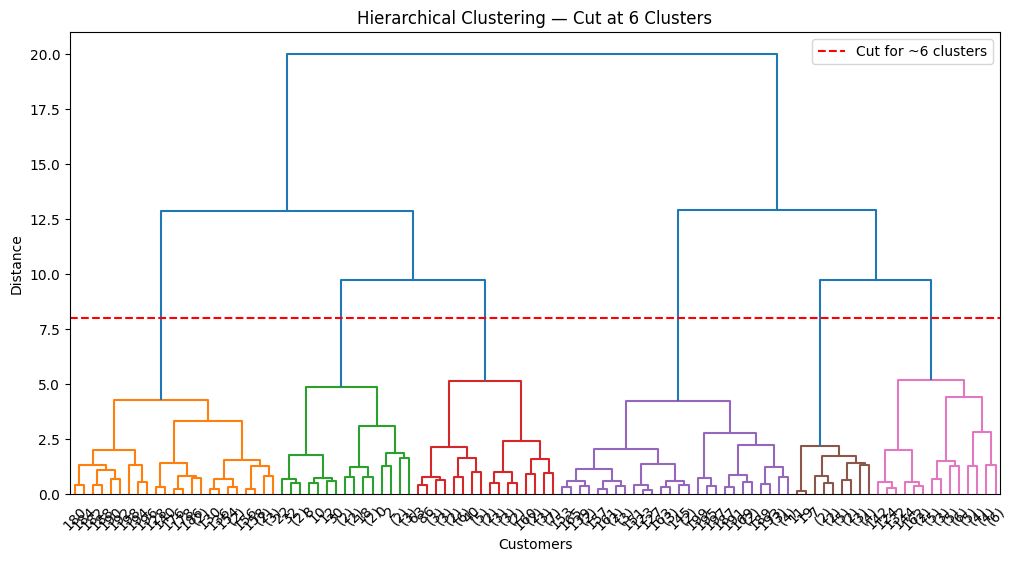

KMeans vs Hierarchical agreement: 1.5%
Adjusted Rand Index: 0.891
(1.0 = perfect agreement, 0.0 = random)


In [15]:
plt.figure(figsize=(12, 6))
linked = linkage(X_scaled, method='ward')
dendrogram(linked,
           truncate_mode='level',
           p=6,
           leaf_rotation=45,
           leaf_font_size=10,
           color_threshold=8)
plt.axhline(y=8, color='red', linestyle='--',
            label='Cut for ~6 clusters')
plt.title('Hierarchical Clustering — Cut at 6 Clusters')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.legend()
plt.show()


from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=6)
df['HC_Cluster'] = hc.fit_predict(X_scaled)


agreement = (df['Cluster'] == df['HC_Cluster']).mean() * 100
print(f"KMeans vs Hierarchical agreement: {agreement:.1f}%")

from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(df['Cluster'], df['HC_Cluster'])
print(f"Adjusted Rand Index: {ari:.3f}")
print("(1.0 = perfect agreement, 0.0 = random)")

In [16]:


dbscan = DBSCAN(eps=0.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(df['DBSCAN_Cluster'])) - \
             (1 if -1 in df['DBSCAN_Cluster'] else 0)
n_noise    = (df['DBSCAN_Cluster'] == -1).sum()

print(f"Clusters found: {n_clusters}")
print(f"Noise points:   {n_noise}")
print(f"Cluster counts:\n{df['DBSCAN_Cluster'].value_counts()}")

Clusters found: 7
Noise points:   60
Cluster counts:
DBSCAN_Cluster
-1    60
 2    51
 4    32
 3    28
 0    17
 5     7
 1     5
Name: count, dtype: int64


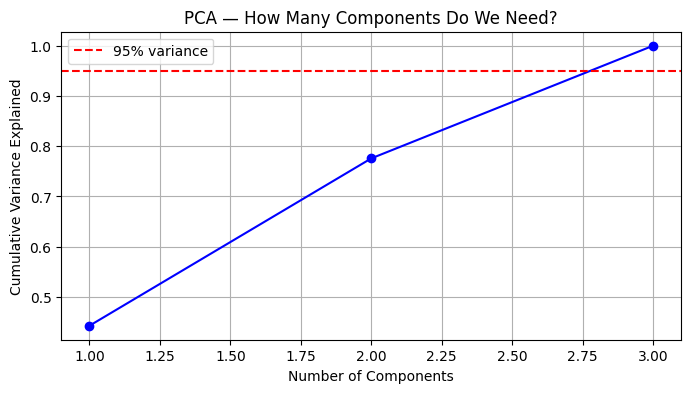

Components 1: 44.3% variance explained
Components 2: 77.6% variance explained
Components 3: 100.0% variance explained


In [18]:
from sklearn.decomposition import PCA
import numpy as np


pca = PCA()
pca.fit(X_scaled)


cumvar = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, 'bo-')
plt.axhline(y=0.95, color='red', linestyle='--',
            label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('PCA — How Many Components Do We Need?')
plt.legend()
plt.grid(True)
plt.show()

for i, var in enumerate(cumvar):
    print(f"Components {i+1}: {var:.1%} variance explained")

In [19]:
comparison = pd.DataFrame({
    'Algorithm': ['K-Means', 'Hierarchical', 'DBSCAN'],
    'Clusters Found': [6, 6, 7],
    'Noise Points': [0, 0, 60],
    'Agrees with KMeans': [' Base', '89.1%', ' Different'],
    'Best For': [
        'Known K, round clusters',
        'Visual dendrogram, hierarchy',
        'Irregular shapes, outlier detection'
    ]
})

print(comparison.to_string(index=False))

print("\n BUSINESS RECOMMENDATIONS:")
print("="*50)
profiles = df.groupby('Cluster')[['Age', 'Annual Income (k$)',
                                   'Spending Score (1-100)']].mean().round(1)
segments = {
    0: 'Middle-aged Average',
    1: 'Young Average',
    2: 'Careful Savers',
    3: 'VIP Customers',
    4: 'Impulsive Spenders',
    5: 'Budget Customers'
}

for cluster, name in segments.items():
    row = profiles.loc[cluster]
    print(f"Cluster {cluster} — {name}")
    print(f"  Age:{row['Age']} | Income:{row['Annual Income (k$)']}k | Score:{row['Spending Score (1-100)']}")
    print()

   Algorithm  Clusters Found  Noise Points Agrees with KMeans                            Best For
     K-Means               6             0               Base             Known K, round clusters
Hierarchical               6             0              89.1%        Visual dendrogram, hierarchy
      DBSCAN               7            60          Different Irregular shapes, outlier detection

 BUSINESS RECOMMENDATIONS:
Cluster 0 — Middle-aged Average
  Age:56.3 | Income:54.3k | Score:49.1

Cluster 1 — Young Average
  Age:26.8 | Income:57.1k | Score:48.1

Cluster 2 — Careful Savers
  Age:41.9 | Income:88.9k | Score:17.0

Cluster 3 — VIP Customers
  Age:32.7 | Income:86.5k | Score:82.1

Cluster 4 — Impulsive Spenders
  Age:25.0 | Income:25.3k | Score:77.6

Cluster 5 — Budget Customers
  Age:45.5 | Income:26.3k | Score:19.4

